# Gas de Esferas Duras en 2D

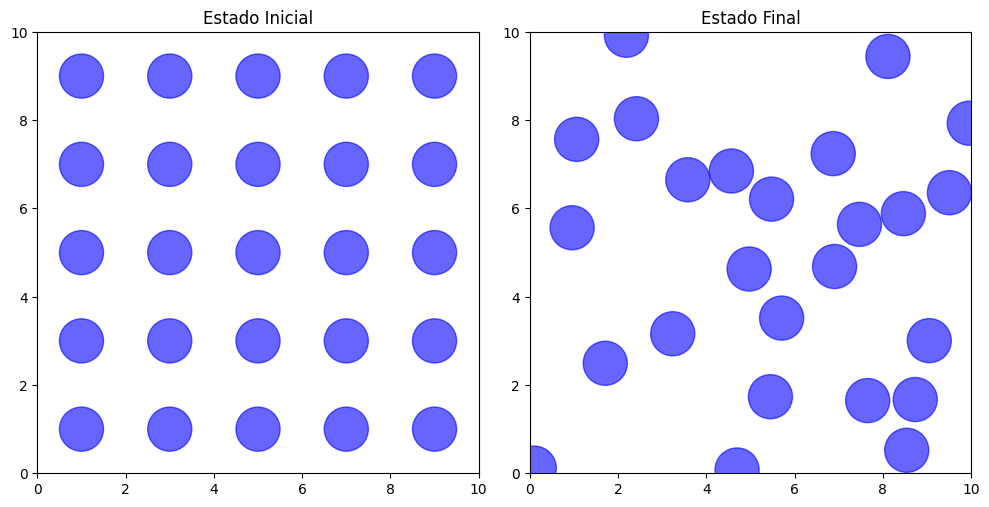

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Red inicial ordenada
def init_grid(N_sqrt, L):
    spacing = L / N_sqrt
    x = np.linspace(spacing/2, L-spacing/2, N_sqrt)
    y = np.linspace(spacing/2, L-spacing/2, N_sqrt)
    xv, yv = np.meshgrid(x, y)
    return np.column_stack((xv.flatten(), yv.flatten()))

# Restricciones físicas
def get_dist_sq(p1, p2, L):
    """Convención de Mínima Imagen."""
    dx = p1[0] - p2[0]
    dy = p1[1] - p2[1]
    # Aplicar PBC y Mínima Imagen
    dx -= L * np.round(dx / L)
    dy -= L * np.round(dy / L)
    return dx**2 + dy**2

def check_overlap(pos, i, L, sigma):
    """Verifica traslape con cualquier otra partícula."""
    sigma_sq = sigma**2
    for j in range(len(pos)):
        if i == j: continue
        if get_dist_sq(pos[i], pos[j], L) < sigma_sq:
            return True
    return False

# Motor Metropolis-Hastings
def run_simulation(N_sqrt, L, sigma, steps, delta, mu_bias=0.0):
    N = N_sqrt**2
    pos = init_grid(N_sqrt, L)
    pos_inicial = np.copy(pos)

    for step in range(steps):
        i = np.random.randint(N)
        old_pos_i = np.copy(pos[i])

        # Propuesta con sesgo (mu_bias)
        dx = mu_bias + np.random.normal(0, delta)
        dy = np.random.normal(0, delta)

        new_pos_i = np.array([(old_pos_i[0] + dx) % L, (old_pos_i[1] + dy) % L])

        # Calcular Factor de Hasting
        hastings_ratio = np.exp(-(mu_bias / delta**2) * dx)

        pos[i] = new_pos_i

        # Verificar Traslape
        if check_overlap(pos, i, L, sigma):
            pos[i] = old_pos_i
        else:
            if np.random.rand() > min(1.0, hastings_ratio):
                pos[i] = old_pos_i

    return pos_inicial, pos

# Visualización
def plot_results(p_ini, p_fin, L, sigma):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    estados = [p_ini, p_fin]
    titulos = ["Estado Inicial", "Estado Final"]

    for ax, pos, title in zip(axes, estados, titulos):
        ax.set_xlim(0, L); ax.set_ylim(0, L)
        ax.set_aspect('equal')
        ax.set_title(title)
        for p in pos:
            ax.add_patch(Circle(p, sigma/2, color='blue', alpha=0.6))
    plt.tight_layout()
    plt.show()

# Ejecución
L, sigma, N_sqrt = 10.0, 1.0, 5
p_ini, p_fin = run_simulation(N_sqrt, L, sigma, steps=20000, delta=0.5, mu_bias=0.0)
plot_results(p_ini, p_fin, L, sigma)

## Tasa de Aceptación

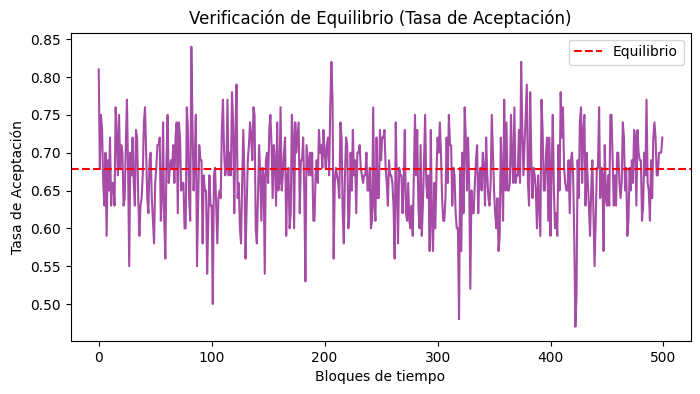

In [60]:
import numpy as np
import matplotlib.pyplot as plt

def run_simulation_with_monitoring(N_sqrt, L, sigma, steps, delta, mu_bias=0.0):
    N = N_sqrt**2
    pos = init_grid(N_sqrt, L)

    # Registro de aceptación para monitorear equilibrio
    history_acceptance = []
    block_size = 100 # tasa cada 100 pasos
    accepted_in_block = 0

    for step in range(steps):
        i = np.random.randint(N)
        old_pos_i = np.copy(pos[i])

        # Propuesta
        dx = mu_bias + np.random.normal(0, delta)
        dy = np.random.normal(0, delta)
        new_pos_i = np.array([(old_pos_i[0] + dx) % L, (old_pos_i[1] + dy) % L])

        hastings_ratio = np.exp(-(mu_bias / delta**2) * dx)

        # Traslape
        pos[i] = new_pos_i
        if check_overlap(pos, i, L, sigma):
            pos[i] = old_pos_i
        else:
            if np.random.rand() < min(1.0, hastings_ratio):
                accepted_in_block += 1
            else:
                pos[i] = old_pos_i

        # Registrar tasa
        if (step + 1) % block_size == 0:
            history_acceptance.append(accepted_in_block / block_size)
            accepted_in_block = 0

    return history_acceptance

# Ejecucuión y Visualización
steps = 50000
acc_rate = run_simulation_with_monitoring(5, 10.0, 1.0, steps, 0.5)

plt.figure(figsize=(8, 4))
plt.plot(acc_rate, color='purple', alpha=0.7)
plt.axhline(y=np.mean(acc_rate[-50:]), color='red', linestyle='--', label='Equilibrio')
plt.title("Verificación de Equilibrio (Tasa de Aceptación)")
plt.xlabel("Bloques de tiempo")
plt.ylabel("Tasa de Aceptación")
plt.legend()
plt.show()

# Estudio de los observables

## Función de Distribución Radial

<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_5334/2268687985.py:32: SyntaxWarning: invalid escape sequence '\s'
  plt.axvline(sigma, color='red', linestyle='--', label='Diámetro $\sigma$')


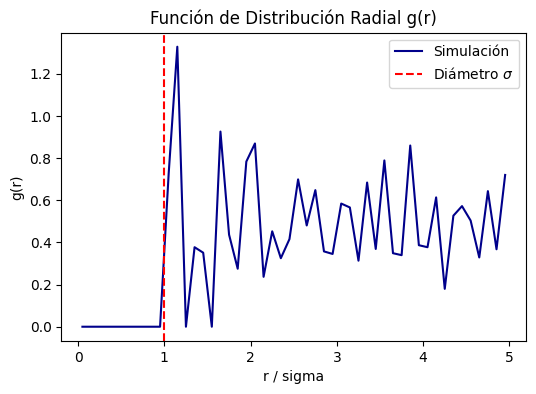

In [61]:
def calcular_g_r(pos, L, sigma, bins=50):
    """
    Calcula la función de distribución radial g(r).
    """
    N = len(pos)
    rho = N / (L**2)
    distancias = []

    # Calcular distancias entre todos los pares sin repetir
    for i in range(N):
        for j in range(i + 1, N):
            d2 = get_dist_sq(pos[i], pos[j], L)
            distancias.append(np.sqrt(d2))

    r_max = L / 2
    hist, edges = np.histogram(distancias, bins=bins, range=(0, r_max))
    r = (edges[:-1] + edges[1:]) / 2
    dr = edges[1] - edges[0]

    # Normalización
    # Se divide por el área de la corona circular
    shell_area = 2 * np.pi * r * dr
    g_r = hist / (N * rho * shell_area)

    return r, g_r

# Ejecución y Visualización
r_axis, gr = calcular_g_r(p_fin, L, sigma)

plt.figure(figsize=(6, 4))
plt.plot(r_axis, gr, label='Simulación', color='darkblue')
plt.axvline(sigma, color='red', linestyle='--', label='Diámetro $\sigma$')
plt.title("Función de Distribución Radial g(r)")
plt.xlabel("r / sigma")
plt.ylabel("g(r)")
plt.legend()
plt.show()

## Energía y Velocidad vs Temperatura

<>:37: SyntaxWarning: invalid escape sequence '\s'
<>:37: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_5334/1503299054.py:37: SyntaxWarning: invalid escape sequence '\s'
  ax2.plot(T_range, v_teos, 'r--', label='Teoría ($v = \sqrt{2 k_B T / m}$)')


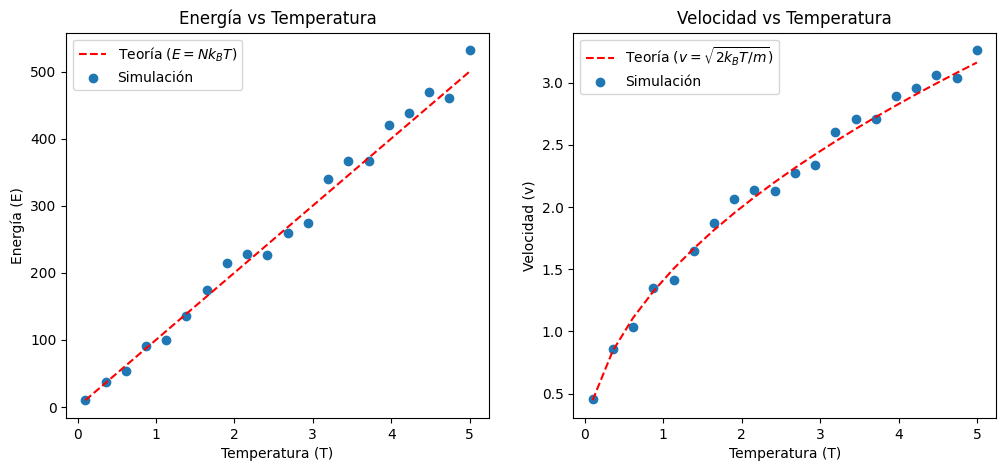

In [62]:
import numpy as np
import matplotlib.pyplot as plt

def get_stats(T, N, m=1.0, kB=1.0):
    # Generar muestras de Velocidades
    std = np.sqrt(kB * T / m)
    vx = np.random.normal(0, std, N)
    vy = np.random.normal(0, std, N)
    v_mag = np.sqrt(vx**2 + vy**2)

    # Observables calculados
    E_sim = np.mean(0.5 * m * (vx**2 + vy**2)) * N
    v_rms_sim = np.sqrt(np.mean(v_mag**2))

    # Observables teóricos
    E_teo = N * kB * T
    v_rms_teo = np.sqrt(2 * kB * T / m)

    return E_sim, E_teo, v_rms_sim, v_rms_teo

# Estudio
T_range = np.linspace(0.1, 5.0, 20)
results = [get_stats(T, N=100) for T in T_range]
E_sims, E_teos, v_sims, v_teos = zip(*results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Ploteo E vs T
ax1.plot(T_range, E_teos, 'r--', label='Teoría ($E = N k_B T$)')
ax1.scatter(T_range, E_sims, label='Simulación')
ax1.set_title("Energía vs Temperatura")
ax1.set_xlabel("Temperatura (T)")
ax1.set_ylabel("Energía (E)")
ax1.legend()

# Plot v vs T
ax2.plot(T_range, v_teos, 'r--', label='Teoría ($v = \sqrt{2 k_B T / m}$)')
ax2.scatter(T_range, v_sims, label='Simulación')
ax2.set_title("Velocidad vs Temperatura")
ax2.set_xlabel("Temperatura (T)")
ax2.set_ylabel("Velocidad (v)")
ax2.legend()

plt.show()

## Distribución de Maxwell-Boltzmann

In [63]:
def plot_maxwell_boltzmann(v_mag, T, m=1.0, kB=1.0):

    """
    Compara el histograma de velocidades medidas con la curva teórica.
    """
    plt.figure(figsize=(8, 5))

    # Histograma de la simulación
    plt.hist(v_mag, bins=25, density=True, alpha=0.6, color='skyblue', label='Simulación (Muestreo)')

    # Curva teórica de Maxwell-Boltzmann en 2D
    v_axis = np.linspace(0, max(v_mag)*1.2, 100)
    mb_teorica = (m * v_axis / (kB * T)) * np.exp(-m * v_axis**2 / (2 * kB * T))

    plt.plot(v_axis, mb_teorica, color='red', linewidth=2.5, label='Teoría (Maxwell-Boltzmann)')

    plt.title(f"Distribución de Velocidades (T={T})")
    plt.xlabel("Velocidad (v)")
    plt.ylabel("Densidad de Probabilidad P(v)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

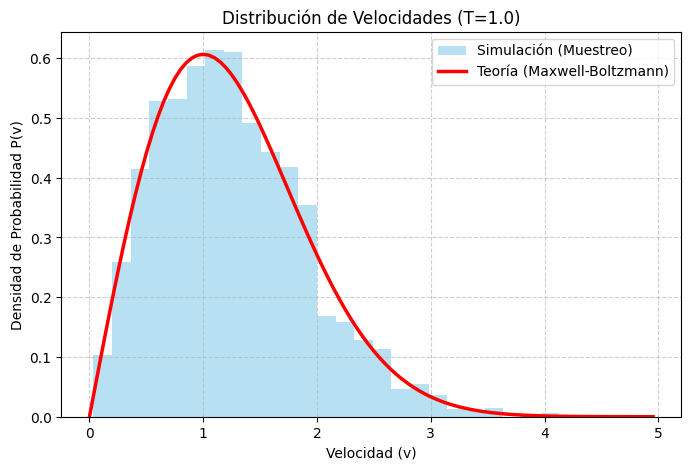

In [64]:
import numpy as np

# Paremetros Físicos
T = 1.0
m = 1.0
kB = 1.0
N_muestras = 2000

# Datos
vx = np.random.normal(0, np.sqrt(kB * T / m), N_muestras)
vy = np.random.normal(0, np.sqrt(kB * T / m), N_muestras)
v_mag = np.sqrt(vx**2 + vy**2)

plot_maxwell_boltzmann(v_mag, T=T, m=m, kB=kB)